In [3]:
!pip install datasets

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [78]:
base_path = "/content/drive/MyDrive/CustomerSupportAI"

In [79]:
model.save_pretrained(f"{base_path}/intent_model")
tokenizer.save_pretrained(f"{base_path}/intent_model")

torch.save(label_encoder, f"{base_path}/intent_label_encoder.pt")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [80]:
import os
print(os.listdir(base_path))

['emotion_model', 'emotion_label_encoder.pt', 'intent_model', 'intent_label_encoder.pt']


# Dataset 1

In [6]:
from datasets import load_dataset

banking = load_dataset("banking77")

print(banking)
print(banking["train"][0])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/298k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})
{'text': 'I am still waiting on my card?', 'label': 11}


### maping and extracting banking dataset


In [7]:
from datasets import load_dataset

banking = load_dataset("banking77")

label_names = banking["train"].features["label"].names
print(label_names)

['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit', 'beneficiary_not_allowed', 'cancel_transfer', 'card_about_to_expire', 'card_acceptance', 'card_arrival', 'card_delivery_estimate', 'card_linking', 'card_not_working', 'card_payment_fee_charged', 'card_payment_not_recognised', 'card_payment_wrong_exchange_rate', 'card_swallowed', 'cash_withdrawal_charge', 'cash_withdrawal_not_recognised', 'change_pin', 'compromised_card', 'contactless_not_working', 'country_support', 'declined_card_payment', 'declined_cash_withdrawal', 'declined_transfer', 'direct_debit_payment_not_recognised', 'disposable_card_limits', 'edit_personal_details', 'exchange_charge', 'exchange_rate', 'exchange_via_app', 'extra_charge_on_statement', 'failed_transfer', 'fiat_currency_support', 'get_disposable_virtual_card', 'get_physical_card', 'getting_spare_card', 'getting_virtual_card'

In [8]:
cancel_request = [
    "cancel_transfer",
    "terminate_account"
]
refund_replace = [
    "request_refund",
    "Refund_not_showing_up",
    "reverted_card_payment?",
    "transaction_charged_twice"
]
complaint = [
    "card_not_working",
    "declined_card_payment",
    "declined_cash_withdrawal",
    "declined_transfer",
    "transfer_not_received_by_recipient",
    "wrong_amount_of_cash_received",
    "wrong_exchange_rate_for_cash_withdrawal",
    "card_swallowed",
    "lost_or_stolen_card",
    "virtual_card_not_working",
    "top_up_failed"
]
inquiry = [
    "exchange_rate",
    "card_delivery_estimate",
    "transfer_timing",
    "balance_not_updated_after_bank_transfer",
    "balance_not_updated_after_cheque_or_cash_deposit",
    "country_support",
    "fiat_currency_support",
    "supported_cards_and_currencies",
    "age_limit",
    "visa_or_mastercard"
]
support_request = [
    "activate_my_card",
    "change_pin",
    "edit_personal_details",
    "get_physical_card",
    "get_disposable_virtual_card",
    "getting_virtual_card",
    "getting_spare_card",
    "order_physical_card",
    "passcode_forgotten",
    "pin_blocked",
    "verify_my_identity",
    "verify_source_of_funds",
    "verify_top_up",
    "unable_to_verify_identity"
]

In [9]:
mapping = {}

for label in cancel_request:
    mapping[label] = "cancel_request"

for label in refund_replace:
    mapping[label] = "refund_replace"

for label in complaint:
    mapping[label] = "complaint"

for label in inquiry:
    mapping[label] = "inquiry"

for label in support_request:
    mapping[label] = "support_request"

In [10]:
import pandas as pd

data = []

for example in banking["train"]:
    original_label = banking["train"].features["label"].names[example["label"]]

    if original_label in mapping:
        data.append({
            "text": example["text"],
            "label": mapping[original_label]
        })

expanded_df = pd.DataFrame(data)

print("Total samples:", len(expanded_df))
print(expanded_df['label'].value_counts())

Total samples: 5296
label
support_request    1617
complaint          1414
inquiry            1333
refund_replace      667
cancel_request      265
Name: count, dtype: int64


# Dataset 2

In [22]:
clinc["train"].features["intent"].names[:30]

['restaurant_reviews',
 'nutrition_info',
 'account_blocked',
 'oil_change_how',
 'time',
 'weather',
 'redeem_rewards',
 'interest_rate',
 'gas_type',
 'accept_reservations',
 'smart_home',
 'user_name',
 'report_lost_card',
 'repeat',
 'whisper_mode',
 'what_are_your_hobbies',
 'order',
 'jump_start',
 'schedule_meeting',
 'meeting_schedule',
 'freeze_account',
 'what_song',
 'meaning_of_life',
 'restaurant_reservation',
 'traffic',
 'make_call',
 'text',
 'bill_balance',
 'improve_credit_score',
 'change_language']

In [13]:
from datasets import load_dataset

clinc = load_dataset("clinc_oos", "plus")

print(clinc)
print(clinc["train"][0])

README.md: 0.00B [00:00, ?B/s]

plus/train-00000-of-00001.parquet:   0%|          | 0.00/312k [00:00<?, ?B/s]

plus/validation-00000-of-00001.parquet:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

plus/test-00000-of-00001.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15250 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})
{'text': 'what expression would i use to say i love you if i were an italian', 'intent': 61}


In [14]:
clinc_labels = clinc["train"].features["intent"].names

mapping_clinc = {
    "restaurant_reviews": "feedback",
    "account_blocked": "complaint",
    "report_lost_card": "complaint",
    "freeze_account": "complaint",
    "bill_balance": "inquiry",
    "interest_rate": "inquiry"
}

clinc_data = []

for example in clinc["train"]:
    original_label = clinc_labels[example["intent"]]

    if original_label in mapping_clinc:
        clinc_data.append({
            "text": example["text"],
            "label": mapping_clinc[original_label]
        })

clinc_df = pd.DataFrame(clinc_data)

print(len(clinc_df))
print(clinc_df['label'].value_counts())

600
label
complaint    300
inquiry      200
feedback     100
Name: count, dtype: int64


In [15]:
final_df = pd.concat([expanded_df, clinc_df])
final_df = final_df.drop_duplicates()

In [16]:
mapping_clinc = {
    "restaurant_reviews": "feedback",
    "account_blocked": "complaint",
    "report_lost_card": "complaint",
    "freeze_account": "complaint",
    "interest_rate": "inquiry",
    "bill_balance": "inquiry",
    "nutrition_info": "inquiry",
    "accept_reservations": "inquiry",
    "redeem_rewards": "support_request",
    "order": "support_request",
    "schedule_meeting": "support_request",
    "change_language": "support_request"
}

clinc_labels = clinc["train"].features["intent"].names

clinc_data = []

for example in clinc["train"]:
    original_label = clinc_labels[example["intent"]]

    if original_label in mapping_clinc:
        clinc_data.append({
            "text": example["text"],
            "label": mapping_clinc[original_label]
        })

clinc_df = pd.DataFrame(clinc_data)

print("CLINC extracted:", len(clinc_df))
print(clinc_df['label'].value_counts())

CLINC extracted: 1200
label
support_request    400
inquiry            400
complaint          300
feedback           100
Name: count, dtype: int64


# # Dataset 3

In [17]:
snips = load_dataset("snips_built_in_intents")

print(snips)
print(snips["train"][0])

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/328 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 328
    })
})
{'text': "Share my location with Hillary's sister", 'label': 5}


In [18]:
snips = load_dataset("snips_built_in_intents")

print(snips)
print(snips["train"].column_names)
print(snips["train"][0])
print(snips["train"].features)
print(snips["train"].column_names)
print(snips["train"].features)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 328
    })
})
['text', 'label']
{'text': "Share my location with Hillary's sister", 'label': 5}
{'text': Value('string'), 'label': ClassLabel(names=['ComparePlaces', 'RequestRide', 'GetWeather', 'SearchPlace', 'GetPlaceDetails', 'ShareCurrentLocation', 'GetTrafficInformation', 'BookRestaurant', 'GetDirections', 'ShareETA'])}
['text', 'label']
{'text': Value('string'), 'label': ClassLabel(names=['ComparePlaces', 'RequestRide', 'GetWeather', 'SearchPlace', 'GetPlaceDetails', 'ShareCurrentLocation', 'GetTrafficInformation', 'BookRestaurant', 'GetDirections', 'ShareETA'])}


In [19]:
snips_labels = snips["train"].features["label"].names

mapping_snips = {
    "GetWeather": "inquiry",
    "GetTrafficInformation": "inquiry",
    "GetPlaceDetails": "inquiry",
    "SearchPlace": "inquiry",
    "BookRestaurant": "support_request",
    "RequestRide": "support_request",
    "GetDirections": "support_request"
}

snips_data = []

for example in snips["train"]:
    original_label = snips_labels[example["label"]]

    if original_label in mapping_snips:
        snips_data.append({
            "text": example["text"],
            "label": mapping_snips[original_label]
        })

snips_df = pd.DataFrame(snips_data)

print("SNIPS extracted:", len(snips_df))
print(snips_df['label'].value_counts())

SNIPS extracted: 271
label
inquiry            140
support_request    131
Name: count, dtype: int64


In [20]:
final_df = pd.concat([expanded_df, clinc_df, snips_df])
final_df = final_df.drop_duplicates().reset_index(drop=True)

print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())

Final dataset size: 6767
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
cancel_request      265
feedback            100
Name: count, dtype: int64


In [21]:
print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())

Final dataset size: 6767
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
cancel_request      265
feedback            100
Name: count, dtype: int64


In [68]:
import pandas as pd

# Load the new files you created
app_df = pd.read_csv("appreciation (1).csv")
feed_df = pd.read_csv("feedback (1).csv")

# Make sure column names are correct
print(app_df.columns)
print(feed_df.columns)

# If needed, rename columns to match:
# They must be: text , label

# Merge into existing dataset
final_df = pd.concat([final_df, app_df, feed_df])
final_df = final_df.drop_duplicates().reset_index(drop=True)

print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())
final_df.to_csv("final_intent_dataset.csv", index=False)

Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')
Final dataset size: 8067
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
feedback            500
appreciation        500
cancel_request      265
improvement         103
suggestion          103
positive             99
neutral              95
Name: count, dtype: int64


In [24]:
final_df['label'] = final_df['label'].replace({
    'improvement': 'feedback',
    'suggestion': 'feedback',
    'positive': 'feedback',
    'neutral': 'feedback'
})

print(final_df['label'].value_counts())

label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
cancel_request      265
feedback            100
Name: count, dtype: int64


In [25]:
final_df.to_csv("final_intent_dataset.csv", index=False)
import os
print(os.listdir())

['.config', 'drive', 'final_intent_dataset.csv', 'sample_data']


## FULL INTENT TRAINING CODE

In [26]:
print("Total samples:", len(df))
print(df['label'].value_counts())

NameError: name 'df' is not defined

In [27]:
!pip install datasets

# Dataset 1

In [28]:
from datasets import load_dataset

banking = load_dataset("banking77")

print(banking)
print(banking["train"][0])


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})
{'text': 'I am still waiting on my card?', 'label': 11}


### maping and extracting banking dataset


In [29]:
from datasets import load_dataset

banking = load_dataset("banking77")

label_names = banking["train"].features["label"].names
print(label_names)

['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit', 'beneficiary_not_allowed', 'cancel_transfer', 'card_about_to_expire', 'card_acceptance', 'card_arrival', 'card_delivery_estimate', 'card_linking', 'card_not_working', 'card_payment_fee_charged', 'card_payment_not_recognised', 'card_payment_wrong_exchange_rate', 'card_swallowed', 'cash_withdrawal_charge', 'cash_withdrawal_not_recognised', 'change_pin', 'compromised_card', 'contactless_not_working', 'country_support', 'declined_card_payment', 'declined_cash_withdrawal', 'declined_transfer', 'direct_debit_payment_not_recognised', 'disposable_card_limits', 'edit_personal_details', 'exchange_charge', 'exchange_rate', 'exchange_via_app', 'extra_charge_on_statement', 'failed_transfer', 'fiat_currency_support', 'get_disposable_virtual_card', 'get_physical_card', 'getting_spare_card', 'getting_virtual_card'

In [30]:
cancel_request = [
    "cancel_transfer",
    "terminate_account"
]
refund_replace = [
    "request_refund",
    "Refund_not_showing_up",
    "reverted_card_payment?",
    "transaction_charged_twice"
]
complaint = [
    "card_not_working",
    "declined_card_payment",
    "declined_cash_withdrawal",
    "declined_transfer",
    "transfer_not_received_by_recipient",
    "wrong_amount_of_cash_received",
    "wrong_exchange_rate_for_cash_withdrawal",
    "card_swallowed",
    "lost_or_stolen_card",
    "virtual_card_not_working",
    "top_up_failed"
]
inquiry = [
    "exchange_rate",
    "card_delivery_estimate",
    "transfer_timing",
    "balance_not_updated_after_bank_transfer",
    "balance_not_updated_after_cheque_or_cash_deposit",
    "country_support",
    "fiat_currency_support",
    "supported_cards_and_currencies",
    "age_limit",
    "visa_or_mastercard"
]
support_request = [
    "activate_my_card",
    "change_pin",
    "edit_personal_details",
    "get_physical_card",
    "get_disposable_virtual_card",
    "getting_virtual_card",
    "getting_spare_card",
    "order_physical_card",
    "passcode_forgotten",
    "pin_blocked",
    "verify_my_identity",
    "verify_source_of_funds",
    "verify_top_up",
    "unable_to_verify_identity"
]

In [31]:
mapping = {}

for label in cancel_request:
    mapping[label] = "cancel_request"

for label in refund_replace:
    mapping[label] = "refund_replace"

for label in complaint:
    mapping[label] = "complaint"

for label in inquiry:
    mapping[label] = "inquiry"

for label in support_request:
    mapping[label] = "support_request"

In [32]:
import pandas as pd

data = []

for example in banking["train"]:
    original_label = banking["train"].features["label"].names[example["label"]]

    if original_label in mapping:
        data.append({
            "text": example["text"],
            "label": mapping[original_label]
        })

expanded_df = pd.DataFrame(data)

print("Total samples:", len(expanded_df))
print(expanded_df['label'].value_counts())

Total samples: 5296
label
support_request    1617
complaint          1414
inquiry            1333
refund_replace      667
cancel_request      265
Name: count, dtype: int64


# Dataset 2

In [33]:
clinc["train"].features["intent"].names[:30]

['restaurant_reviews',
 'nutrition_info',
 'account_blocked',
 'oil_change_how',
 'time',
 'weather',
 'redeem_rewards',
 'interest_rate',
 'gas_type',
 'accept_reservations',
 'smart_home',
 'user_name',
 'report_lost_card',
 'repeat',
 'whisper_mode',
 'what_are_your_hobbies',
 'order',
 'jump_start',
 'schedule_meeting',
 'meeting_schedule',
 'freeze_account',
 'what_song',
 'meaning_of_life',
 'restaurant_reservation',
 'traffic',
 'make_call',
 'text',
 'bill_balance',
 'improve_credit_score',
 'change_language']

In [34]:
from datasets import load_dataset

clinc = load_dataset("clinc_oos", "plus")

print(clinc)
print(clinc["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'intent'],
        num_rows: 15250
    })
    validation: Dataset({
        features: ['text', 'intent'],
        num_rows: 3100
    })
    test: Dataset({
        features: ['text', 'intent'],
        num_rows: 5500
    })
})
{'text': 'what expression would i use to say i love you if i were an italian', 'intent': 61}


In [35]:
clinc_labels = clinc["train"].features["intent"].names

mapping_clinc = {
    "restaurant_reviews": "feedback",
    "account_blocked": "complaint",
    "report_lost_card": "complaint",
    "freeze_account": "complaint",
    "bill_balance": "inquiry",
    "interest_rate": "inquiry"
}

clinc_data = []

for example in clinc["train"]:
    original_label = clinc_labels[example["intent"]]

    if original_label in mapping_clinc:
        clinc_data.append({
            "text": example["text"],
            "label": mapping_clinc[original_label]
        })

clinc_df = pd.DataFrame(clinc_data)

print(len(clinc_df))
print(clinc_df['label'].value_counts())

600
label
complaint    300
inquiry      200
feedback     100
Name: count, dtype: int64


In [36]:
final_df = pd.concat([expanded_df, clinc_df])
final_df = final_df.drop_duplicates()

In [37]:
mapping_clinc = {
    "restaurant_reviews": "feedback",
    "account_blocked": "complaint",
    "report_lost_card": "complaint",
    "freeze_account": "complaint",
    "interest_rate": "inquiry",
    "bill_balance": "inquiry",
    "nutrition_info": "inquiry",
    "accept_reservations": "inquiry",
    "redeem_rewards": "support_request",
    "order": "support_request",
    "schedule_meeting": "support_request",
    "change_language": "support_request"
}

clinc_labels = clinc["train"].features["intent"].names

clinc_data = []

for example in clinc["train"]:
    original_label = clinc_labels[example["intent"]]

    if original_label in mapping_clinc:
        clinc_data.append({
            "text": example["text"],
            "label": mapping_clinc[original_label]
        })

clinc_df = pd.DataFrame(clinc_data)

print("CLINC extracted:", len(clinc_df))
print(clinc_df['label'].value_counts())

CLINC extracted: 1200
label
support_request    400
inquiry            400
complaint          300
feedback           100
Name: count, dtype: int64


# # Dataset 3

In [38]:
snips = load_dataset("snips_built_in_intents")

print(snips)
print(snips["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 328
    })
})
{'text': "Share my location with Hillary's sister", 'label': 5}


In [39]:
snips = load_dataset("snips_built_in_intents")

print(snips)
print(snips["train"].column_names)
print(snips["train"][0])
print(snips["train"].features)
print(snips["train"].column_names)
print(snips["train"].features)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 328
    })
})
['text', 'label']
{'text': "Share my location with Hillary's sister", 'label': 5}
{'text': Value('string'), 'label': ClassLabel(names=['ComparePlaces', 'RequestRide', 'GetWeather', 'SearchPlace', 'GetPlaceDetails', 'ShareCurrentLocation', 'GetTrafficInformation', 'BookRestaurant', 'GetDirections', 'ShareETA'])}
['text', 'label']
{'text': Value('string'), 'label': ClassLabel(names=['ComparePlaces', 'RequestRide', 'GetWeather', 'SearchPlace', 'GetPlaceDetails', 'ShareCurrentLocation', 'GetTrafficInformation', 'BookRestaurant', 'GetDirections', 'ShareETA'])}


In [40]:
snips_labels = snips["train"].features["label"].names

mapping_snips = {
    "GetWeather": "inquiry",
    "GetTrafficInformation": "inquiry",
    "GetPlaceDetails": "inquiry",
    "SearchPlace": "inquiry",
    "BookRestaurant": "support_request",
    "RequestRide": "support_request",
    "GetDirections": "support_request"
}

snips_data = []

for example in snips["train"]:
    original_label = snips_labels[example["label"]]

    if original_label in mapping_snips:
        snips_data.append({
            "text": example["text"],
            "label": mapping_snips[original_label]
        })

snips_df = pd.DataFrame(snips_data)

print("SNIPS extracted:", len(snips_df))
print(snips_df['label'].value_counts())

SNIPS extracted: 271
label
inquiry            140
support_request    131
Name: count, dtype: int64


In [41]:
final_df = pd.concat([expanded_df, clinc_df, snips_df])
final_df = final_df.drop_duplicates().reset_index(drop=True)

print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())

Final dataset size: 6767
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
cancel_request      265
feedback            100
Name: count, dtype: int64


In [42]:
print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())

Final dataset size: 6767
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
cancel_request      265
feedback            100
Name: count, dtype: int64


In [56]:
import pandas as pd

# Load the new files you created
app_df = pd.read_csv("appreciation (1).csv")
feed_df = pd.read_csv("feedback (1).csv")

# Make sure column names are correct
print(app_df.columns)
print(feed_df.columns)

# If needed, rename columns to match:
# They must be: text , label

# Merge into existing dataset
final_df = pd.concat([final_df, app_df, feed_df])
final_df = final_df.drop_duplicates().reset_index(drop=True)

print("Final dataset size:", len(final_df))
print(final_df['label'].value_counts())
final_df.to_csv("final_intent_dataset.csv", index=False)

Index(['text', 'label'], dtype='object')
Index(['text', 'label'], dtype='object')
Final dataset size: 7667
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
appreciation        500
cancel_request      265
improvement         103
suggestion          103
feedback            100
positive             99
neutral              95
Name: count, dtype: int64


In [57]:
final_df['label'] = final_df['label'].replace({
    'improvement': 'feedback',
    'suggestion': 'feedback',
    'positive': 'feedback',
    'neutral': 'feedback'
})

print(final_df['label'].value_counts())

label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
feedback            500
appreciation        500
cancel_request      265
Name: count, dtype: int64


In [58]:
final_df.to_csv("final_intent_dataset.csv", index=False)
import os
print(os.listdir())

['.config', 'appreciation (1).csv', 'feedback (1).csv', 'drive', 'final_intent_dataset.csv', 'best_intent_model.pt', 'sample_data']


## FULL INTENT TRAINING CODE

In [59]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import clip_grad_norm_
from tqdm import tqdm

In [60]:
import pandas as pd

df = pd.read_csv("final_intent_dataset.csv")

print("Total samples:", len(df))
print(df['label'].value_counts())

Total samples: 7667
label
support_request    2148
inquiry            1873
complaint          1714
refund_replace      667
feedback            500
appreciation        500
cancel_request      265
Name: count, dtype: int64


## Proper 70 / 15 / 15 Split

In [61]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['label'],
    random_state=42
)

print(len(train_df), len(val_df), len(test_df))

5366 1150 1151


## Encode labels

In [62]:
label_encoder = LabelEncoder()

train_df['label_enc'] = label_encoder.fit_transform(train_df['label'])
val_df['label_enc'] = label_encoder.transform(val_df['label'])
test_df['label_enc'] = label_encoder.transform(test_df['label'])

num_labels = len(label_encoder.classes_)
print("Number of classes:", num_labels)

Number of classes: 7


## Create dataset class

In [63]:
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

## Initialize Model (roberta-base)

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("roberta-base")

model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=num_labels
).to(device)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Compute class weights ad create dataloaders

In [65]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label_enc']),
    y=train_df['label_enc']
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
train_dataset = IntentDataset(
    train_df['text'],
    train_df['label_enc'],
    tokenizer
)

val_dataset = IntentDataset(
    val_df['text'],
    val_df['label_enc'],
    tokenizer
)

test_dataset = IntentDataset(
    test_df['text'],
    test_df['label_enc'],
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

## optimize+scheduler

In [66]:
optimizer = AdamW(model.parameters(), lr=2e-5)

total_steps = len(train_loader) * 5

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

## Training Loop (With Early Stopping)

In [67]:
best_val_loss = float('inf')
patience = 2
counter = 0

for epoch in range(5):

    model.train()
    train_loss = 0

    for batch in tqdm(train_loader):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)

        loss.backward()
        clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(f"\nEpoch {epoch+1}")
    print("Train Loss:", avg_train_loss)
    print("Val Loss:", avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_intent_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

100%|██████████| 336/336 [01:08<00:00,  4.93it/s]



Epoch 1
Train Loss: 0.8688166163795229
Val Loss: 0.1322160862877758


100%|██████████| 336/336 [01:07<00:00,  4.96it/s]



Epoch 2
Train Loss: 0.09997087803674817
Val Loss: 0.08014878537182489


100%|██████████| 336/336 [01:07<00:00,  4.95it/s]



Epoch 3
Train Loss: 0.05274114257051787
Val Loss: 0.09225735079154321


100%|██████████| 336/336 [01:09<00:00,  4.82it/s]



Epoch 4
Train Loss: 0.02530867739482173
Val Loss: 0.09273599178252173
Early stopping triggered


## Final Evaluation on TEST


TEST RESULTS
                 precision    recall  f1-score   support

   appreciation       1.00      1.00      1.00        75
 cancel_request       0.97      0.95      0.96        40
      complaint       0.97      0.97      0.97       257
       feedback       1.00      0.99      0.99        75
        inquiry       0.99      0.94      0.96       281
 refund_replace       0.94      0.95      0.95       100
support_request       0.95      1.00      0.97       323

       accuracy                           0.97      1151
      macro avg       0.97      0.97      0.97      1151
   weighted avg       0.97      0.97      0.97      1151



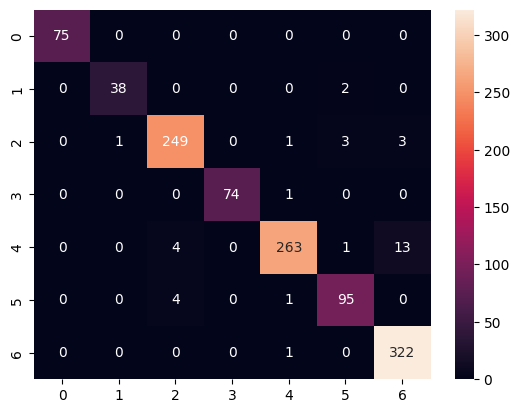

In [69]:
model.load_state_dict(torch.load("best_intent_model.pt"))
model.eval()

preds = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(outputs.logits, dim=1)

        preds.extend(predictions.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

print("\nTEST RESULTS")
print(classification_report(
    true_labels,
    preds,
    target_names=label_encoder.classes_
))

cm = confusion_matrix(true_labels, preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [70]:
train_texts = set(train_df['text'])
test_texts = set(test_df['text'])

overlap = train_texts.intersection(test_texts)
print("Train-Test Overlap:", len(overlap))

Train-Test Overlap: 0


In [71]:
print("Total duplicates:", df.duplicated(subset=["text"]).sum())

Total duplicates: 0


In [72]:
print(test_df['label'].value_counts())

label
support_request    323
inquiry            281
complaint          257
refund_replace     100
appreciation        75
feedback            75
cancel_request      40
Name: count, dtype: int64


In [73]:
shuffled_labels = np.random.permutation(train_df['label_enc'])

## Save the model

In [74]:
model.save_pretrained("intent_model")
tokenizer.save_pretrained("intent_model")
torch.save(label_encoder, "intent_label_encoder.pt")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [76]:
!ls

'appreciation (1).csv'	'feedback (1).csv'	    intent_model
 best_intent_model.pt	 final_intent_dataset.csv   sample_data
 drive			 intent_label_encoder.pt


In [77]:
from google.colab import _message
from google.colab import files
import json

# Get notebook JSON
nb = _message.blocking_request('get_ipynb', timeout_sec=5)

# Extract notebook name safely
metadata = nb.get('ipynb', {}).get('metadata', {})
colab_meta = metadata.get('colab', {})

nb_name = colab_meta.get('name', 'downloaded_notebook.ipynb')

print("Notebook name:", nb_name)

# Save notebook to runtime
with open(nb_name, 'w') as f:
    json.dump(nb['ipynb'], f)

# Download to your computer
files.download(nb_name)

Notebook name: downloaded_notebook.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>